# 03 · Sample Design and Data Quality

Layers 1–2 of the feature-selection funnel: **business / compliance exclusions** and **data quality**.
All decisions use the **development sample only (weeks 0–50)**; OOT1 / OOT2 are never used for selection.

**Sample design**

| Period | Weeks | Role |
|---|---|---|
| Train | 0–40 | model fitting |
| Valid | 41–50 | internal validation: early stopping, feature choices, cut-off setting |
| OOT1 | 51–62 | out-of-time test — risk deterioration (bad rate rising to >5%) |
| OOT2 | 63–91 | out-of-time test — post-COVID population shift |

Features are checked table by table against the development sample, so the full feature matrix is never held in memory.

**Outputs** (`results/`): `base_split.parquet`, `03_feature_quality.parquet/.csv`, `age.parquet`

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))

import gc
import time

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from hcrisk.config import BOUNDS, FEAT_DIR, RES_DIR, TRAIN_END, VALID_END, period_expr, savefig
from hcrisk.io import NON_FEATURES, scan

TABLE_FILES = [f for f in sorted(FEAT_DIR.glob("*.parquet")) if f.stem not in ("depth0", "tax_unified")]
ALL_FILES = [FEAT_DIR / "depth0.parquet"] + TABLE_FILES
print([f.stem for f in ALL_FILES])

['depth0', 'applprev_1', 'applprev_2', 'credit_bureau_a_1', 'credit_bureau_a_2', 'credit_bureau_b_1', 'credit_bureau_b_2', 'debitcard_1', 'deposit_1', 'other_1', 'person_1', 'person_2', 'tax_registry_a_1', 'tax_registry_b_1', 'tax_registry_c_1']


## 1. Sample split

In [2]:
base = (pl.read_parquet(FEAT_DIR / "depth0.parquet", columns=["case_id", "WEEK_NUM", "date_decision", "target"])
          .with_columns(period_expr()))
base.write_parquet(RES_DIR / "base_split.parquet")        # every later notebook uses this split
display(base.group_by("period").agg(
    pl.col("WEEK_NUM").min().alias("week_from"), pl.col("WEEK_NUM").max().alias("week_to"),
    pl.len().alias("n"), pl.col("target").sum().alias("n_bad"),
    pl.col("target").mean().round(4).alias("bad_rate")).sort("period"))
dev = base.filter(pl.col("WEEK_NUM") <= VALID_END).select("case_id", "WEEK_NUM", "target")

period,week_from,week_to,n,n_bad,bad_rate
str,i64,i64,u32,i64,f64
"""1_train""",0,40,778703,22554,0.029
"""2_valid""",41,50,251298,9239,0.0368
"""3_oot1""",51,62,237744,10142,0.0427
"""4_oot2""",63,91,258914,6059,0.0234


## 2. Data-source coverage over time
If a source is switched on or off at some point, a model can learn *"has a record in source X"* as a proxy for
*time*, which hurts stability. In the full data this chart reveals the tax-registry vendor switches (c → a → b),
a credit-bureau field expansion around week 22, and `other_1` starting only in week ~53.

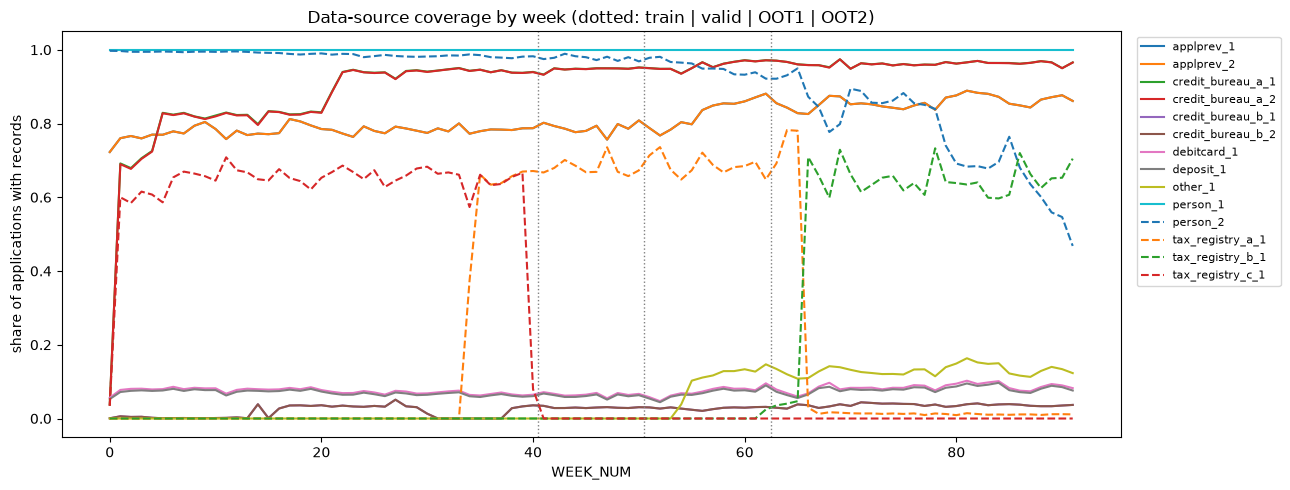

period,applprev_1,applprev_2,credit_bureau_a_1,credit_bureau_a_2,credit_bureau_b_1,credit_bureau_b_2,debitcard_1,deposit_1,other_1,person_1,person_2,tax_registry_a_1,tax_registry_b_1,tax_registry_c_1
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""1_train""",0.779,0.779,0.862,0.861,0.017,0.017,0.073,0.069,0.0,1.0,0.988,0.127,0.0,0.619
"""2_valid""",0.787,0.787,0.948,0.947,0.03,0.03,0.065,0.061,0.0,1.0,0.978,0.681,0.0,0.0
"""3_oot1""",0.823,0.823,0.956,0.956,0.028,0.028,0.071,0.067,0.075,1.0,0.956,0.689,0.002,0.0
"""4_oot2""",0.857,0.857,0.963,0.963,0.036,0.036,0.084,0.079,0.129,1.0,0.746,0.093,0.581,0.0


In [3]:
tables = [f.stem for f in TABLE_FILES]
cov = base.select("case_id", "WEEK_NUM", "period")
for f in TABLE_FILES:
    cov = cov.join(pl.read_parquet(f, columns=["case_id"]).with_columns(pl.lit(1, pl.Int8).alias(f.stem)),
                   on="case_id", how="left")
cov = cov.with_columns(pl.col(tables).fill_null(0))
weekly_cov = cov.group_by("WEEK_NUM").agg([pl.col(t).mean() for t in tables]).sort("WEEK_NUM")

fig, ax = plt.subplots(figsize=(13, 5))
for i, t in enumerate(tables):
    ax.plot(weekly_cov["WEEK_NUM"], weekly_cov[t], label=t, ls="-" if i < 10 else "--")
for x in BOUNDS:
    ax.axvline(x, color="grey", ls=":", lw=1)
ax.set_xlabel("WEEK_NUM"); ax.set_ylabel("share of applications with records")
ax.set_title("Data-source coverage by week (dotted: train | valid | OOT1 | OOT2)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout(); savefig(fig, "03_source_coverage"); plt.show()
display(cov.group_by("period").agg([pl.col(t).mean().round(3) for t in tables]).sort("period"))
del cov; _ = gc.collect()

## 3. Feature-level quality (development sample)
Missing rates are computed **after joining to all applications** (cases without records count as missing),
separately for train (0–40) and valid (41–50) to spot sources that change within the development period.

In [4]:
rows, t0 = [], time.time()
for f in ALL_FILES:
    feat = (pl.scan_parquet(f).drop([c for c in NON_FEATURES if c != "case_id"], strict=False)
              .join(dev.lazy().select("case_id"), on="case_id", how="semi").collect())
    d = dev.select("case_id", "WEEK_NUM").join(feat, on="case_id", how="left")
    del feat
    is_train = d["WEEK_NUM"] <= TRAIN_END
    n_tr, n_va = is_train.sum(), d.height - is_train.sum()
    for c in d.columns:
        if c in ("case_id", "WEEK_NUM"):
            continue
        s = d[c]
        null = s.is_null()
        nn = s.drop_nulls()
        rows.append({"table": f.stem, "feature": c, "dtype": str(s.dtype),
                     "null_dev": null.mean(), "null_train": (null & is_train).sum() / n_tr,
                     "null_valid": (null & ~is_train).sum() / n_va, "n_unique": nn.n_unique(),
                     "top_share": (nn.value_counts(sort=True)["count"][0] / nn.len()) if nn.len() else 1.0})
    print(f"{f.stem:20s} {d.width - 2:>4} features  {time.time() - t0:5.0f}s")
    del d; _ = gc.collect()
q = pl.DataFrame(rows)

depth0                187 features      6s


applprev_1             77 features      9s


applprev_2              7 features      9s


credit_bureau_a_1     147 features     15s


credit_bureau_a_2      33 features     17s


...

deposit_1               7 features     18s
other_1                11 features     18s


person_1               66 features     21s


person_2               17 features     22s
tax_registry_a_1        7 features     22s


tax_registry_b_1        7 features     22s


tax_registry_c_1        7 features     23s


## 4. Exclusion rules
**Dropped** (in priority order):
1. Gender fields — compliance
2. Birth-date / age fields — age is used only as an admission rule (notebook 09), not as a model feature
3. Missing > 95% in the development sample
4. Single value, or top value > 99% of non-missing rows

**Flagged for review** (kept): missing rate differs by > 20 pp between train and valid (source change inside the
development period), or a string feature with > 200 categories. Gender-proxy checks are done in notebook 04.

In [5]:
q = q.with_columns(
    pl.when(pl.col("feature").str.contains("(?i)(sex|gender)")).then(pl.lit("gender field (compliance)"))
      .when(pl.col("feature").str.contains("(?i)birth")).then(pl.lit("age field (admission rule only)"))
      .when(pl.col("null_dev") > 0.95).then(pl.lit("missing > 95%"))
      .when(pl.col("n_unique") <= 1).then(pl.lit("single value"))
      .when(pl.col("top_share") > 0.99).then(pl.lit("near-constant (> 99%)"))
      .otherwise(None).alias("drop_reason"),
    pl.concat_str([
        pl.when((pl.col("null_train") - pl.col("null_valid")).abs() > 0.2).then(pl.lit("coverage change in dev; ")),
        pl.when((pl.col("dtype") == "String") & (pl.col("n_unique") > 200)).then(pl.lit("high-cardinality category; ")),
    ], ignore_nulls=True).alias("review_flag"),
).with_columns(pl.when(pl.col("review_flag") == "").then(None).otherwise(pl.col("review_flag")).alias("review_flag"))

print(f"features checked: {q.height} | kept: {q['drop_reason'].is_null().sum()}")
display(q.group_by("drop_reason").len().sort("len", descending=True))
display(q.filter(pl.col("drop_reason").is_null() & pl.col("review_flag").is_not_null())
         .select("table", "feature", "null_train", "null_valid", "n_unique", "review_flag").sort("review_flag", "table"))

features checked: 672 | kept: 455


drop_reason,len
str,u32
null,455
"""missing > 95%""",145
"""near-constant (> 99%)""",45
"""single value""",17
"""age field (admission rule only…",6
"""gender field (compliance)""",4


table,feature,null_train,null_valid,n_unique,review_flag
str,str,f64,f64,i64,str
"""credit_bureau_a_1""","""dpdmax_757P__mean""",0.531542,0.170367,31605,"""coverage change in dev; """
"""credit_bureau_a_1""","""overdueamountmaxdateyear_994T_…",0.531498,0.170288,113273,"""coverage change in dev; """
"""credit_bureau_a_1""","""overdueamountmaxdateyear_994T_…",0.531498,0.170288,3555,"""coverage change in dev; """
"""credit_bureau_a_1""","""dpdmaxdateyear_896T_yrsago__me…",0.531542,0.170367,112668,"""coverage change in dev; """
"""credit_bureau_a_1""","""dpdmaxdateyear_896T_yrsago__ma…",0.531542,0.170367,3549,"""coverage change in dev; """
…,…,…,…,…,…
"""person_1""","""registaddr_zipcode_184M__first""",0.0,0.0,3362,"""high-cardinality category; """
"""person_1""","""registaddr_district_1083M__fir…",0.0,0.0,498,"""high-cardinality category; """
"""person_1""","""empladdr_zipcode_114M__first""",0.0,0.0,3162,"""high-cardinality category; """


## 5. Age and bad rate (input to the admission rule in notebook 09)
Age is taken from the **applicant's own record** (`person_1`, `num_group1 == 0`), not from the aggregated file,
because `person_1` also contains related persons (e.g. contacts).

candidate coverage (dev): {'age_birth_259D': 1.0, 'age_birthdate_87D': 0.008, 'age_birthdate_574D': 0.59, 'age_dateofbirth_337D': 0.882}


age_band,n,bad_rate,share
enum,u32,f64,f64
"""[-inf, 22)""",12331,0.0681,0.012
"""[22, 25)""",57830,0.051,0.0561
"""[25, 30)""",124948,0.0414,0.1213
"""[30, 35)""",140962,0.0341,0.1369
"""[35, 40)""",127907,0.0319,0.1242
…,…,…,…
"""[45, 50)""",102731,0.0287,0.0997
"""[50, 55)""",86026,0.0271,0.0835
"""[55, 60)""",83503,0.0217,0.0811


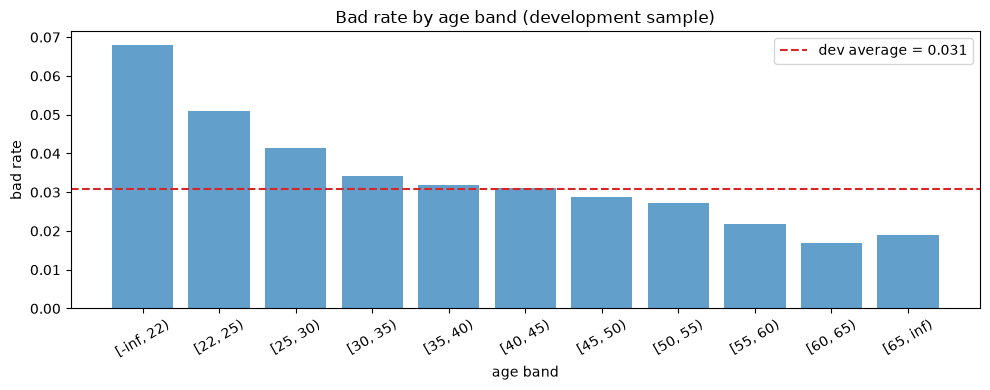

In [6]:
p1 = scan("person_1").filter(pl.col("num_group1") == 0)
p1_birth = [c for c, t in p1.collect_schema().items() if "birth" in c.lower() and t == pl.Date]
d0_birth = [c for c in pl.read_parquet_schema(FEAT_DIR / "depth0.parquet") if "birth" in c.lower()]
age_p1 = (p1.select(["case_id"] + p1_birth).join(base.lazy().select("case_id", "date_decision"), on="case_id", how="inner")
            .select("case_id", *[((pl.col("date_decision") - pl.col(c)).dt.total_days() / 365.25).alias(f"age_{c}") for c in p1_birth])
            .collect())
age_d0 = pl.read_parquet(FEAT_DIR / "depth0.parquet", columns=["case_id"] + d0_birth).select(
    "case_id", *[(-pl.col(c) / 365.25).alias(f"age_{c}") for c in d0_birth])       # depth0 dates are already relative days
ages = base.select("case_id", "WEEK_NUM", "target").join(age_p1, on="case_id", how="left").join(age_d0, on="case_id", how="left")
cand = [c for c in ages.columns if c.startswith("age_")]
dev_ages = ages.filter(pl.col("WEEK_NUM") <= VALID_END)
coverage = {c: 1 - dev_ages[c].null_count() / dev_ages.height for c in cand}
print("candidate coverage (dev):", {k: round(v, 3) for k, v in coverage.items()})
ages = ages.with_columns(pl.coalesce(sorted(cand, key=lambda c: -coverage[c])).alias("age"))
ages.select("case_id", "age").write_parquet(RES_DIR / "age.parquet")

dev_ages = ages.filter(pl.col("WEEK_NUM") <= VALID_END)
band = (dev_ages.filter(pl.col("age").is_between(18, 100))
          .with_columns(pl.col("age").cut([22, 25, 30, 35, 40, 45, 50, 55, 60, 65], left_closed=True).alias("age_band"))
          .group_by("age_band").agg(pl.col("age").min().alias("_min"), pl.len().alias("n"),
                                    pl.col("target").mean().round(4).alias("bad_rate"))
          .sort("_min").drop("_min").with_columns((pl.col("n") / pl.col("n").sum()).round(4).alias("share")))
display(band)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([str(b) for b in band["age_band"]], band["bad_rate"], alpha=0.7)
ax.axhline(dev["target"].mean(), color="C3", ls="--", label=f"dev average = {dev['target'].mean():.3f}")
ax.set_xlabel("age band"); ax.set_ylabel("bad rate"); ax.set_title("Bad rate by age band (development sample)")
ax.legend(); plt.xticks(rotation=30); plt.tight_layout(); savefig(fig, "03_age_badrate"); plt.show()

In the full data the bad rate **falls monotonically with age** (under 22: ~2.2× average; 60+: ~0.6×). This
supports a lower age bound but gives no risk-based reason for an upper bound (see notebook 09).

In [7]:
q.write_parquet(RES_DIR / "03_feature_quality.parquet")
q.write_csv(RES_DIR / "03_feature_quality.csv", include_bom=True)
print("saved: base_split.parquet, 03_feature_quality.parquet/.csv, age.parquet")

saved: base_split.parquet, 03_feature_quality.parquet/.csv, age.parquet
